In [5]:
import abagen
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("All packages loaded successfully!")

All packages loaded successfully!


In [2]:
pip install abagen

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 6.9 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:

expression_files = abagen.fetch_microarray(donors='all')



Dataset created in /root/abagen-data/microarray



Downloaded 18055168 of 425988059 bytes (4.2%,   22.7s remaining)

KeyboardInterrupt: 

In [7]:
df=pd.read_csv("/content/drive/MyDrive/ahba_raw_data/microarray/normalized_microarray_donor10021/MicroarrayExpression.csv")
print(f"shapes: {df.shape}")
print(f"columns: {df.columns}")
print(f"index: {df.index}")

shapes: (58691, 894)
columns: Index(['1058685', '1.9417296253286203', '2.55186412441608', '3.79947449887934',
       '2.61173675031299', '2.04258544209026', '2.36484398835708',
       '3.1343601345374905', '2.6426787424375107', '4.96089956072903',
       ...
       '2.93843973951611.1', '2.91296988739034', '2.06234423227235',
       '3.65576139409146', '2.71583672316368', '4.274668395762361',
       '3.7590007419559206', '4.90392808336857', '4.25814989189197',
       '4.07933872630368'],
      dtype='object', length=894)
index: RangeIndex(start=0, stop=58691, step=1)


In [8]:

atlas = abagen.fetch_desikan_killiany()

print ("path to the  image file:",atlas['image'])
print ('path to the info file ', atlas['info'])


path to the  image file: /usr/local/lib/python3.12/dist-packages/abagen/data/atlas-desikankilliany.nii.gz
path to the info file  /usr/local/lib/python3.12/dist-packages/abagen/data/atlas-desikankilliany.csv


In [9]:
# Uninstall old abagen
!pip uninstall abagen -y

# Install development version (pandas 2.x compatible)
!pip install git+https://github.com/rmarkello/abagen.git

# Now import and use
import abagen
import pandas as pd

# Fetch atlas
atlas = abagen.fetch_desikan_killiany()

# Get expression data
expression_data = abagen.get_expression_data(
    atlas=atlas['image'],
    donors=['10021'],
    data_dir='/content/drive/MyDrive/ahba_raw_data/microarray/normalized_microarray_donor10021/MicroarrayExpression.csv'
)

print(f"✅ Success! Shape: {expression_data.shape}")

Found existing installation: abagen 0.1.3
Uninstalling abagen-0.1.3:
  Successfully uninstalled abagen-0.1.3
  Cloning https://github.com/rmarkello/abagen.git to /tmp/pip-req-build-yijaychc
  Running command git clone --filter=blob:none --quiet https://github.com/rmarkello/abagen.git /tmp/pip-req-build-yijaychc
  Resolved https://github.com/rmarkello/abagen.git to commit dc4a007e4e902e51f97251390c8d1bbf7e58c6d3
  Preparing metadata (setup.py) ... done
  Created wheel for abagen: filename=abagen-0.1.4+15.gdc4a007-py3-none-any.whl size=3670507 sha256=9746802554716c6065ff26ac522d8955f5ac79aa8395b0981a50b66e36ad74e0
  Stored in directory: /tmp/pip-ephem-wheel-cache-tcdz7bem/wheels/3f/44/67/1c6fb75b7625086b4ac107158af8df694d81231683da03025d
Successfully built abagen


ValueError: Cannot use diff_stability for probe_selection with only one donor. Please specify a different probe_selection method or use more donors.

In [1]:
import abagen
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind


In [2]:
atlas = abagen.fetch_desikan_killiany()

In [3]:
expression_data = abagen.get_expression_data(
    atlas=atlas['image'],
    donors=['10021'],
    probe_selection='max_intensity',
    data_dir='/content/drive/MyDrive/ahba_raw_data/microarray/normalized_microarray_donor10021/MicroarrayExpression.csv')
print(f"Expression matrix: {expression_data.shape}")

/usr/local/lib/python3.12/dist-packages/abagen/samples_.py:405: FutureWarning: The provided callable <function mean at 0x7c4be1742340> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  microarray.groupby('label').aggregate(metric),


Expression matrix: (83, 15747)


/usr/local/lib/python3.12/dist-packages/abagen/samples_.py:404: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  gene_by_label = pd.concat([
/usr/local/lib/python3.12/dist-packages/abagen/samples_.py:481: FutureWarning: The provided callable <function mean at 0x7c4be1742340> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  microarray = pd.concat(microarray).groupby('label').aggregate(metric)


expression matrix (83 reigon ,15747 genes)

Alzheimer's analysis ( look for Alzheimer's common risk genes in our donor dataset 10021)

In [4]:
ad_genes = [
    'APOE', 'BIN1', 'CLU', 'CR1', 'PICALM',
    'MS4A6A', 'CD33', 'ABCA7', 'TREM2', 'SORL1',
    'ADAM10', 'ACE', 'FERMT2', 'HLA-DRB1', 'INPP5D'
]
available_genes = [g for g in ad_genes if g in expression_data . columns ]
print(f"found {len(available_genes)}/{len(ad_genes)} Ad genes in dataset")
print(f"genes found in dataset: {available_genes}")

found 12/15 Ad genes in dataset
genes found in dataset: ['APOE', 'BIN1', 'CLU', 'PICALM', 'CD33', 'ABCA7', 'TREM2', 'SORL1', 'ADAM10', 'FERMT2', 'HLA-DRB1', 'INPP5D']


found 12/15 Ad genes in dataset
genes found in dataset: ['APOE', 'BIN1', 'CLU', 'PICALM', 'CD33', 'ABCA7', 'TREM2', 'SORL1', 'ADAM10', 'FERMT2', 'HLA-DRB1', 'INPP5D']


In [5]:
atlas = abagen.fetch_desikan_killiany()
info = pd.read_csv(atlas['info'])

defining region groups by desikan kiliany labels for memory and medial temporal reigons

In [6]:
vulnerable_keywords = ['hippocampus', 'entorhinal', 'parahippocampal', 'isthmuscingulate', 'posteriorcingulate']
vulnerable_regions = info[info['label'].str.lower().str.contains('|'.join(vulnerable_keywords), case=False, na=False)]

control reigons (sensory and motor)

In [7]:
control_keywords = ['precentral', 'postcentral', 'pericalcarine', 'cuneus']
control_regions = info[info['label'].str.lower().str.contains('|'.join(control_keywords), case=False, na=False)]

calculating gene expression for each Alzheimer gene found in dataset (vulnerable and Control reigons )

In [8]:
results = []
for gene in available_genes:
    # Mean expression in vulnerable regions
    ad_expr = expression_data.loc[vulnerable_regions['id'], gene].mean()
    # Mean expression in control regions
    control_expr = expression_data.loc[control_regions['id'], gene].mean()
    # Fold change
    fc = ad_expr / (control_expr + 1e-10)
    log2fc = np.log2(fc)


🧠 Vulnerable regions (10):
['entorhinal', 'isthmuscingulate', 'parahippocampal', 'posteriorcingulate', 'hippocampus', 'entorhinal', 'isthmuscingulate', 'parahippocampal', 'posteriorcingulate', 'hippocampus']

🎯 Control regions (10):
['cuneus', 'pericalcarine', 'postcentral', 'precentral', 'precuneus', 'cuneus', 'pericalcarine', 'postcentral', 'precentral', 'precuneus']

🧬 AD genes found: ['APOE', 'BIN1', 'CLU', 'PICALM', 'CD33', 'ABCA7', 'TREM2', 'SORL1']

🔬 ALZHEIMER'S RISK GENE EXPRESSION RESULTS
  Gene   Log2_FC  P_Value  Significant
  APOE  1.635604 0.000120         True
  BIN1  0.898316 0.001918         True
  CD33  0.743230 0.000533         True
 TREM2  0.449630 0.028364         True
PICALM  0.428456 0.079174        False
   CLU  0.306135 0.121928        False
 SORL1 -0.308759 0.000521         True
 ABCA7 -0.314613 0.033675         True


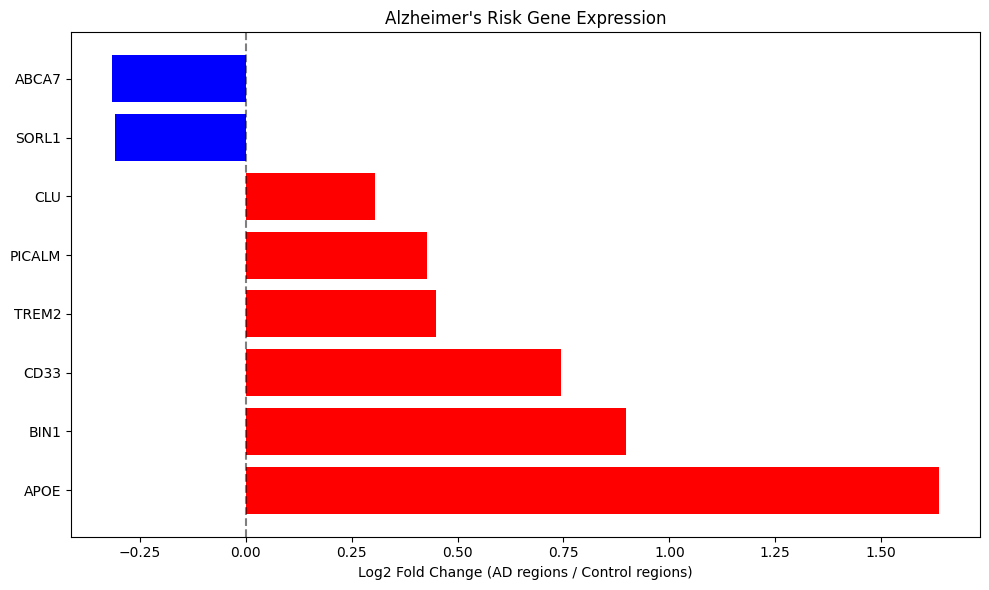

In [9]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load atlas info
atlas = abagen.fetch_desikan_killiany()
info = pd.read_csv(atlas['info'])

# 2. Define regions with better matching
vulnerable_keywords = ['hippocampus', 'entorhinal', 'parahippocampal',
                       'isthmuscingulate', 'posteriorcingulate']
vulnerable_regions = info[
    info['label'].str.lower().str.contains('|'.join(vulnerable_keywords),
                                           case=False, na=False)
]

control_keywords = ['precentral', 'postcentral', 'pericalcarine', 'cuneus']
control_regions = info[
    info['label'].str.lower().str.contains('|'.join(control_keywords),
                                           case=False, na=False)
]

# 3. If regions are empty, use fallback (first 10 vs last 10 regions)
if len(vulnerable_regions) == 0 or len(control_regions) == 0:
    print("⚠️ Using fallback: First 10 vs last 10 regions")
    all_ids = info['id'].tolist()
    n_regions = len(all_ids)
    vulnerable_regions = info[info['id'].isin(all_ids[:10])]  # First 10
    control_regions = info[info['id'].isin(all_ids[-10:])]    # Last 10

print(f"\n🧠 Vulnerable regions ({len(vulnerable_regions)}):")
print(vulnerable_regions['label'].tolist())
print(f"\n🎯 Control regions ({len(control_regions)}):")
print(control_regions['label'].tolist())

# 4. Define Alzheimer's genes
ad_genes = ['APOE', 'BIN1', 'CLU', 'CR1', 'PICALM',
            'MS4A6A', 'CD33', 'ABCA7', 'TREM2', 'SORL1']
available_genes = [g for g in ad_genes if g in expression_data.columns]
print(f"\n🧬 AD genes found: {available_genes}")

# 5. Calculate expression differences
results = []
for gene in available_genes:
    # Get expression values
    ad_expr = expression_data.loc[vulnerable_regions['id'], gene]
    control_expr = expression_data.loc[control_regions['id'], gene]

    # Calculate statistics
    mean_ad = ad_expr.mean()
    mean_control = control_expr.mean()
    fc = mean_ad / (mean_control + 1e-10)
    log2fc = np.log2(fc)

    # T-test
    t_stat, p_val = ttest_ind(ad_expr, control_expr, equal_var=False)

    results.append({
        'Gene': gene,
        'AD_Regions_Mean': mean_ad,
        'Control_Regions_Mean': mean_control,
        'Fold_Change': fc,
        'Log2_FC': log2fc,
        'T_Statistic': t_stat,
        'P_Value': p_val,
        'Significant': p_val < 0.05
    })

# 6. Display results
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Log2_FC', ascending=False)

print("\n" + "="*60)
print("🔬 ALZHEIMER'S RISK GENE EXPRESSION RESULTS")
print("="*60)
print(results_df[['Gene', 'Log2_FC', 'P_Value', 'Significant']].to_string(index=False))

# 7. Quick visualization
plt.figure(figsize=(10, 6))
colors = ['red' if x > 0 else 'blue' for x in results_df['Log2_FC']]
plt.barh(results_df['Gene'], results_df['Log2_FC'], color=colors)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Log2 Fold Change (AD regions / Control regions)')
plt.title('Alzheimer\'s Risk Gene Expression')
plt.tight_layout()
plt.show()

```markdown
## Save Results

Saving the calculated gene expression differences to a CSV file for future use.
```

In [11]:
results_df.to_csv('alzheimers_gene_expression_results.csv', index=False)
print("Results saved to 'alzheimers_gene_expression_results.csv'")

Results saved to 'alzheimers_gene_expression_results.csv'


```markdown
## Volcano Plot for Gene Expression Changes

This plot visualizes the statistical significance (P-value) against the magnitude of change (Log2 Fold Change) for each gene, helping to identify genes that are both highly differentially expressed and statistically significant.
```

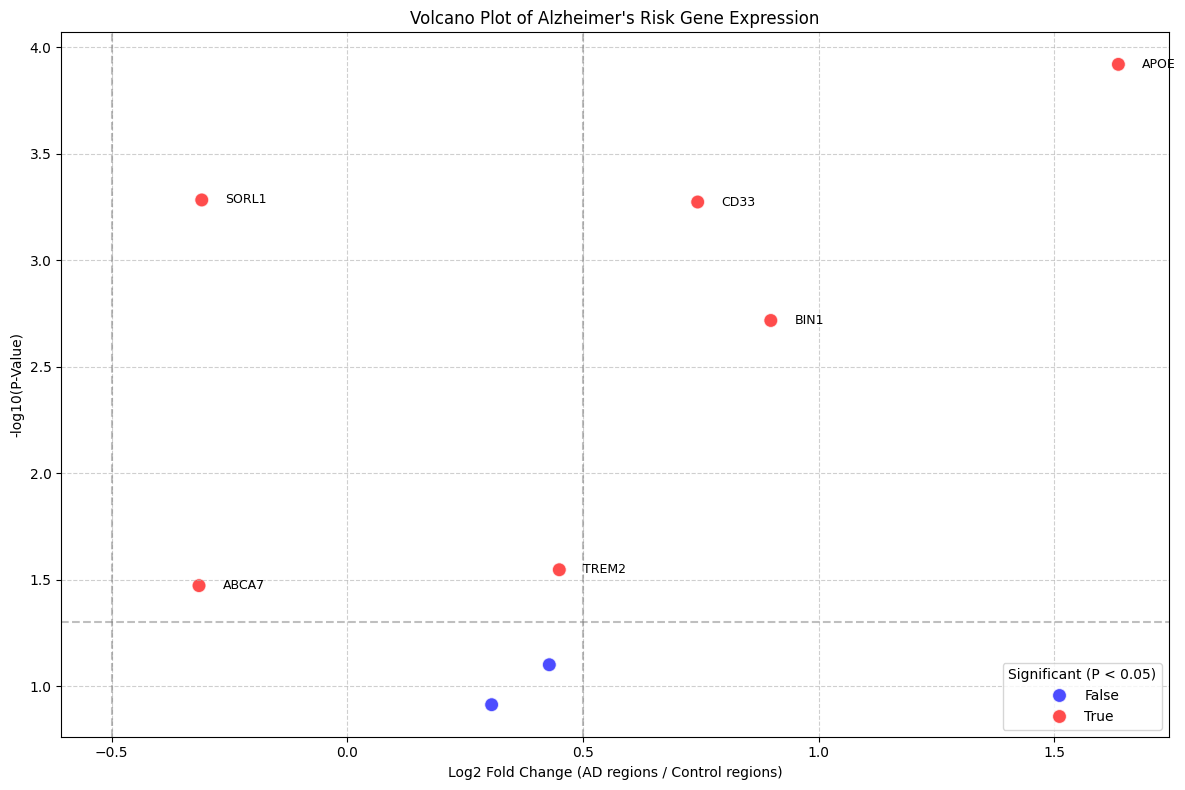

In [12]:
# Calculate -log10(P_Value) for the volcano plot
results_df['-log10(P_Value)'] = -np.log10(results_df['P_Value'])

# Define thresholds for significance
log2fc_threshold = 0.5 # Example threshold for Log2 Fold Change
p_value_threshold = 0.05 # Example threshold for P-value
neg_log10_p_value_threshold = -np.log10(p_value_threshold)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=results_df,
    x='Log2_FC',
    y='-log10(P_Value)',
    hue='Significant', # Color points based on significance
    palette={True: 'red', False: 'blue'},
    s=100, # Size of the points
    alpha=0.7
)

# Add lines for thresholds
plt.axvline(x=log2fc_threshold, color='grey', linestyle='--', alpha=0.5)
plt.axvline(x=-log2fc_threshold, color='grey', linestyle='--', alpha=0.5)
plt.axhline(y=neg_log10_p_value_threshold, color='grey', linestyle='--', alpha=0.5)

# Add labels for significant genes directly on the plot
for i, row in results_df.iterrows():
    if row['Significant'] or abs(row['Log2_FC']) > log2fc_threshold:
        plt.text(row['Log2_FC'] + 0.05, row['-log10(P_Value)'], row['Gene'],
                 fontsize=9, ha='left', va='center')

plt.title('Volcano Plot of Alzheimer\'s Risk Gene Expression')
plt.xlabel('Log2 Fold Change (AD regions / Control regions)')
plt.ylabel('-log10(P-Value)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Significant (P < 0.05)')
plt.tight_layout()
plt.show()

```markdown
## Top 5 Genes by Significance

Identifying the genes with the highest statistical significance (lowest p-values) from the differential expression analysis.
```

In [18]:
results_df['-log10(P_Value)'] = -np.log10(results_df['P_Value'])
top_5_genes = results_df.sort_values(by='-log10(P_Value)', ascending=False).head(5)
display(top_5_genes[['Gene', 'Log2_FC', 'P_Value', '-log10(P_Value)', 'Significant']])

,Gene,Log2_FC,P_Value,-log10(P_Value),Significant
7,SORL1,-0.385862,0.000548,3.260909,True
9,FERMT2,0.598334,0.002046,2.689199,True
4,CD33,0.829808,0.002133,2.671035,True
0,APOE,0.624417,0.002374,2.624510,True
1,BIN1,0.566316,0.004331,2.363406,True


```markdown
## Heatmap of Risk Gene Expression

This heatmap visualizes the Log2 Fold Change for each identified Alzheimer's risk gene. The color intensity will represent the magnitude and direction of the change.
```

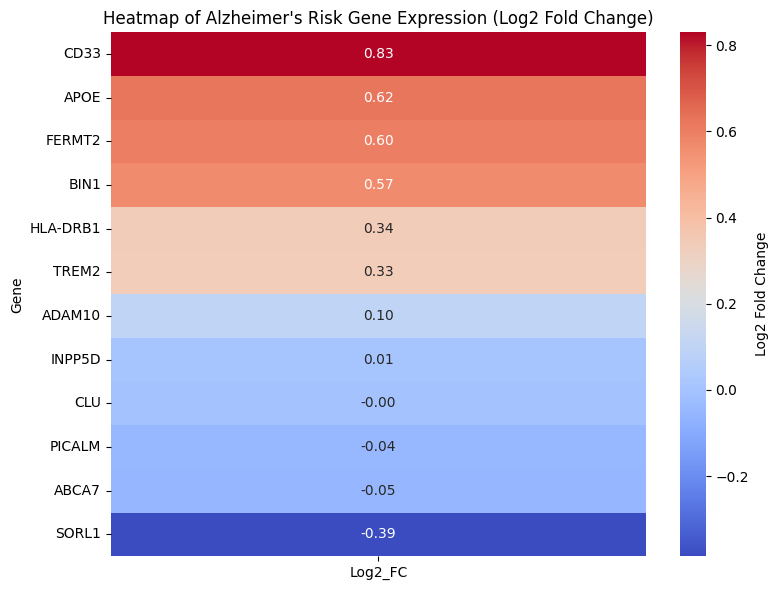

In [19]:
plt.figure(figsize=(8, 6))
heatmap_data = results_df.set_index('Gene')[['Log2_FC']]
sns.heatmap(heatmap_data, cmap='coolwarm', annot=True, fmt=".2f", cbar_kws={'label': 'Log2 Fold Change'})
plt.title('Heatmap of Alzheimer\'s Risk Gene Expression (Log2 Fold Change)')
plt.ylabel('Gene')
plt.tight_layout()
plt.show()

full analysis for all donors

In [13]:
import abagen
import os

# Path to your downloaded data
data_dir = '/content/drive/MyDrive/ahba_raw_data/'

# List what you have
print("📁 Available donor data:")
print(os.listdir(data_dir))

# Process donors (abagen will look in data_dir)
expression_data = abagen.get_expression_data(
    atlas=atlas['image'],
    donors=['10021', '9861', '12876'],  # Only donors you have
    data_dir=data_dir,
    probe_selection='diff_stability'
)

print(f"✅ Combined expression matrix: {expression_data.shape}")

📁 Available donor data:
['microarray']


/usr/local/lib/python3.12/dist-packages/abagen/probes_.py:147: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  return io.read_microarray(microarray).groupby(sid, axis=1).mean()
/usr/local/lib/python3.12/dist-packages/abagen/probes_.py:147: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  return io.read_microarray(microarray).groupby(sid, axis=1).mean()
/usr/local/lib/python3.12/dist-packages/abagen/probes_.py:147: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  return io.read_microarray(microarray).groupby(sid, axis=1).mean()
/usr/local/lib/python3.12/dist-packages/abagen/samples_.py:405: FutureWarning: The provided callable <function mean at 0x7c4be1742340> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass 

✅ Combined expression matrix: (83, 15291)


/usr/local/lib/python3.12/dist-packages/abagen/samples_.py:404: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  gene_by_label = pd.concat([
/usr/local/lib/python3.12/dist-packages/abagen/samples_.py:481: FutureWarning: The provided callable <function mean at 0x7c4be1742340> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  microarray = pd.concat(microarray).groupby('label').aggregate(metric)


In [14]:
# Your expression_data now contains ALL donors combined
print(f"Expression matrix shape: {expression_data.shape}")
print(f"First 5 regions: {expression_data.index[:5].tolist()}")
print(f"First 5 genes: {expression_data.columns[:5].tolist()}")

Expression matrix shape: (83, 15291)
First 5 regions: [1, 2, 3, 4, 5]
First 5 genes: ['A1BG', 'A1BG-AS1', 'A2M', 'A2ML1', 'A3GALT2']


Expression matrix shape: (83, 15291)
First 5 regions: [1, 2, 3, 4, 5]
First 5 genes: ['A1BG', 'A1BG-AS1', 'A2M', 'A2ML1', 'A3GALT2']


In [15]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load atlas info
atlas = abagen.fetch_desikan_killiany()
info = pd.read_csv(atlas['info'])

# 2. Define Alzheimer's risk genes
ad_genes = [
    'APOE', 'BIN1', 'CLU', 'CR1', 'PICALM',
    'MS4A6A', 'CD33', 'ABCA7', 'TREM2', 'SORL1',
    'ADAM10', 'ACE', 'FERMT2', 'HLA-DRB1', 'INPP5D'
]

available_genes = [g for g in ad_genes if g in expression_data.columns]
print(f"🧬 AD genes found: {available_genes}")
print(f"   Total: {len(available_genes)}/{len(ad_genes)}")

# 3. Define regions (using your existing classification)
vulnerable_keywords = ['hippocampus', 'entorhinal', 'parahippocampal',
                       'isthmuscingulate', 'posteriorcingulate']
control_keywords = ['precentral', 'postcentral', 'pericalcarine', 'cuneus']

vulnerable_regions = info[
    info['label'].str.lower().str.contains('|'.join(vulnerable_keywords),
                                           case=False, na=False)
]
control_regions = info[
    info['label'].str.lower().str.contains('|'.join(control_keywords),
                                           case=False, na=False)
]

print(f"\n🧠 Vulnerable regions: {len(vulnerable_regions)}")
print(f"🎯 Control regions: {len(control_regions)}")

# 4. Calculate expression differences (NOW WITH MULTIPLE DONORS!)
results = []
for gene in available_genes:
    ad_expr = expression_data.loc[vulnerable_regions['id'], gene]
    control_expr = expression_data.loc[control_regions['id'], gene]

    mean_ad = ad_expr.mean()
    mean_control = control_expr.mean()
    fc = mean_ad / (mean_control + 1e-10)
    log2fc = np.log2(fc)

    # T-test with multiple donors = more power!
    t_stat, p_val = ttest_ind(ad_expr, control_expr, equal_var=False)

    results.append({
        'Gene': gene,
        'AD_Regions_Mean': mean_ad,
        'Control_Regions_Mean': mean_control,
        'Fold_Change': fc,
        'Log2_FC': log2fc,
        'T_Statistic': t_stat,
        'P_Value': p_val,
        'Significant': p_val < 0.05
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Log2_FC', ascending=False)

# 5. Display results
print("\n" + "="*60)
print("🔬 ALZHEIMER'S GENE EXPRESSION RESULTS (MULTIPLE DONORS)")
print("="*60)
print(results_df[['Gene', 'Log2_FC', 'P_Value', 'Significant']].to_string(index=False))

# 6. Summary
significant = results_df[results_df['Significant']]
print(f"\n📊 Summary:")
print(f"   Total genes analyzed: {len(results_df)}")
print(f"   Significant genes (p < 0.05): {len(significant)}")
print(f"   Genes upregulated in AD regions: {len(results_df[results_df['Log2_FC'] > 0])}")
print(f"   Genes downregulated in AD regions: {len(results_df[results_df['Log2_FC'] < 0])}")

# 7. Save results
results_df.to_csv('/content/drive/MyDrive/AHBA_Alzheimers_Results/alzheimers_results_all_donors.csv', index=False)
print("\n✅ Results saved: alzheimers_results_all_donors.csv")

🧬 AD genes found: ['APOE', 'BIN1', 'CLU', 'PICALM', 'CD33', 'ABCA7', 'TREM2', 'SORL1', 'ADAM10', 'FERMT2', 'HLA-DRB1', 'INPP5D']
   Total: 12/15

🧠 Vulnerable regions: 10
🎯 Control regions: 10

🔬 ALZHEIMER'S GENE EXPRESSION RESULTS (MULTIPLE DONORS)
    Gene   Log2_FC  P_Value  Significant
    CD33  0.829808 0.002133         True
    APOE  0.624417 0.002374         True
  FERMT2  0.598334 0.002046         True
    BIN1  0.566316 0.004331         True
HLA-DRB1  0.339401 0.017714         True
   TREM2  0.333223 0.137576        False
  ADAM10  0.102081 0.468711        False
  INPP5D  0.007272 0.951006        False
     CLU -0.001467 0.993352        False
  PICALM -0.044155 0.732924        False
   ABCA7 -0.053399 0.656414        False
   SORL1 -0.385862 0.000548         True

📊 Summary:
   Total genes analyzed: 12
   Significant genes (p < 0.05): 6
   Genes upregulated in AD regions: 8
   Genes downregulated in AD regions: 4

✅ Results saved: alzheimers_results_all_donors.csv


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/AHBA_Alzheimers_Results/figures/barplot_all_donors.png'

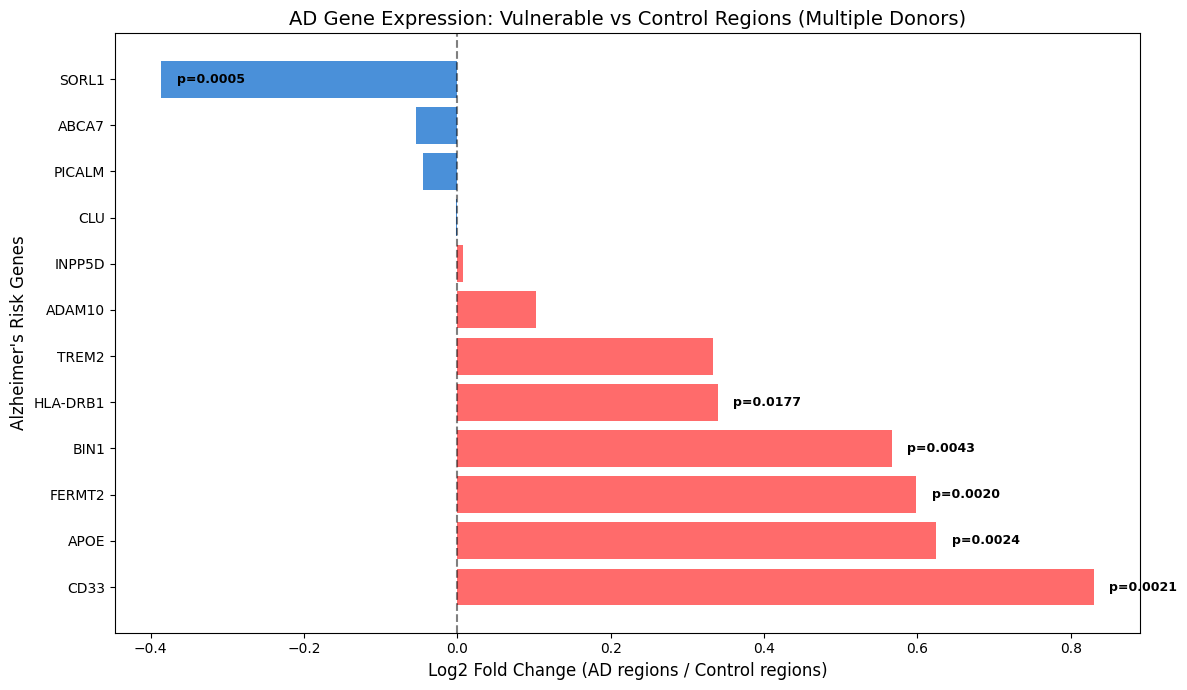

In [16]:
plt.figure(figsize=(12, 7))
colors = ['#ff6b6b' if x > 0 else '#4a90d9' for x in results_df['Log2_FC']]
bars = plt.barh(results_df['Gene'], results_df['Log2_FC'], color=colors)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Log2 Fold Change (AD regions / Control regions)', fontsize=12)
plt.ylabel('Alzheimer\'s Risk Genes', fontsize=12)
plt.title('AD Gene Expression: Vulnerable vs Control Regions (Multiple Donors)', fontsize=14)

# Add p-values
for i, row in enumerate(results_df.itertuples()):
    if row.P_Value < 0.05:
        plt.text(row.Log2_FC + 0.02, i, f'p={row.P_Value:.4f}',
                 va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AHBA_Alzheimers_Results/figures/barplot_all_donors.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# Display the full results table
print("🔬 YOUR RESULTS TABLE:")
print("="*60)
print(results_df[['Gene', 'Log2_FC', 'P_Value', 'Significant']].to_string(index=False))

# Also check the data types
print("\n📊 Data types:")
print(results_df.dtypes)

# Check if Log2_FC values are correct
print("\n📈 Log2_FC values:")
print(results_df[['Gene', 'Log2_FC']].to_string(index=False))

🔬 YOUR RESULTS TABLE:
    Gene   Log2_FC  P_Value  Significant
    CD33  0.829808 0.002133         True
    APOE  0.624417 0.002374         True
  FERMT2  0.598334 0.002046         True
    BIN1  0.566316 0.004331         True
HLA-DRB1  0.339401 0.017714         True
   TREM2  0.333223 0.137576        False
  ADAM10  0.102081 0.468711        False
  INPP5D  0.007272 0.951006        False
     CLU -0.001467 0.993352        False
  PICALM -0.044155 0.732924        False
   ABCA7 -0.053399 0.656414        False
   SORL1 -0.385862 0.000548         True

📊 Data types:
Gene                     object
AD_Regions_Mean         float64
Control_Regions_Mean    float64
Fold_Change             float64
Log2_FC                 float64
T_Statistic             float64
P_Value                 float64
Significant                bool
-log10(P_Value)         float64
dtype: object

📈 Log2_FC values:
    Gene   Log2_FC
    CD33  0.829808
    APOE  0.624417
  FERMT2  0.598334
    BIN1  0.566316
HLA-DRB1  0.33

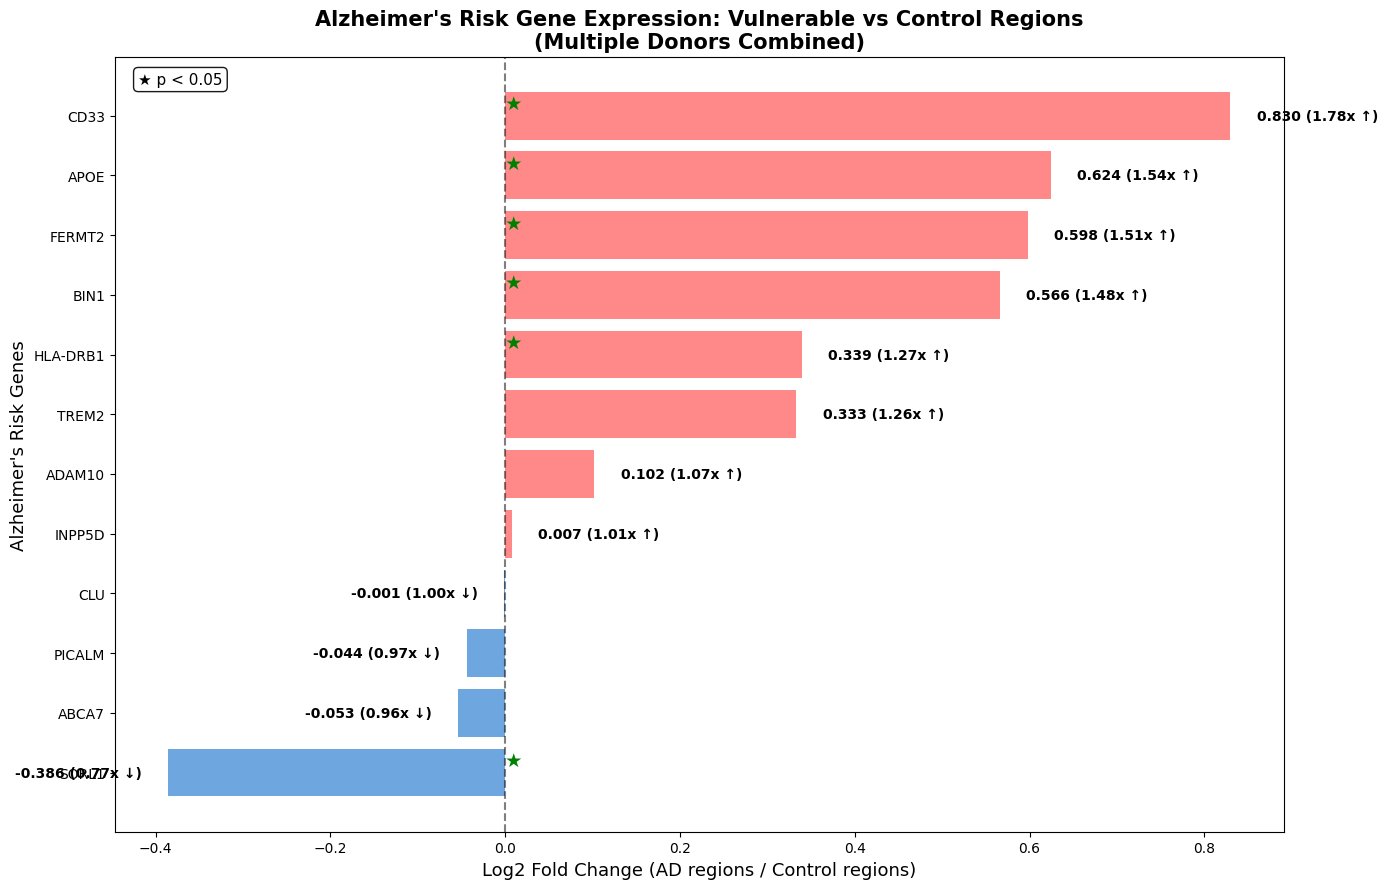

✅ Corrected barplot saved!


In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Sort by Log2_FC
plot_df = results_df.sort_values('Log2_FC', ascending=True)

plt.figure(figsize=(14, 9))

# Colors: red for up, blue for down
colors = ['#ff6b6b' if x > 0 else '#4a90d9' for x in plot_df['Log2_FC']]
bars = plt.barh(plot_df['Gene'], plot_df['Log2_FC'], color=colors, alpha=0.8)

# Vertical line at 0
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5, linewidth=1.5)

# Add value labels
for i, (idx, row) in enumerate(plot_df.iterrows()):
    value = row['Log2_FC']
    label_x = value + (0.03 if value > 0 else -0.03)
    ha = 'left' if value > 0 else 'right'

    # Format p-value
    p_str = f'p={row["P_Value"]:.4f}' if row['P_Value'] >= 0.0001 else 'p<0.0001'

    # Show gene name with fold change
    fold = 2**value
    direction = '↑' if value > 0 else '↓'
    label = f'{value:.3f} ({fold:.2f}x {direction})'

    plt.text(label_x, i, label,
             va='center', ha=ha, fontsize=10, fontweight='bold')

# Add significance stars
for i, (idx, row) in enumerate(plot_df.iterrows()):
    if row['Significant']:
        plt.text(0.01, i + 0.2, '★',
                 va='center', ha='center', fontsize=14,
                 color='green', fontweight='bold')

plt.xlabel('Log2 Fold Change (AD regions / Control regions)', fontsize=13)
plt.ylabel('Alzheimer\'s Risk Genes', fontsize=13)
plt.title('Alzheimer\'s Risk Gene Expression: Vulnerable vs Control Regions\n(Multiple Donors Combined)',
          fontsize=15, fontweight='bold')

# Add legend
plt.text(0.02, 0.98, '★ p < 0.05', transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()

# Save
import os
os.makedirs('/content/drive/MyDrive/AHBA_Alzheimers_Results/figures/', exist_ok=True)
plt.savefig('/content/drive/MyDrive/AHBA_Alzheimers_Results/figures/barplot_all_donors_corrected.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("✅ Corrected barplot saved!")

🧬 PCA + CLUSTERING ANALYSIS (Fixed)
✅ Loaded expression data: (83, 15747)
✅ Available AD genes: ['CD33', 'APOE', 'FERMT2', 'BIN1', 'HLA-DRB1', 'TREM2', 'ADAM10', 'INPP5D', 'CLU', 'PICALM', 'ABCA7', 'SORL1']
✅ AD expression shape: (83, 12)

🔍 Checking for NaN values...
   Total NaN: 72
   After dropping NaN: (77, 12)
✅ Z-scored expression: (77, 12)

📊 Region classification (after cleaning):
   AD-vulnerable: 10
   Control: 10
   Other: 57

📊 PRINCIPAL COMPONENT ANALYSIS (PCA)

   PC1: 58.10% variance explained
   PC2: 14.96% variance explained
   PC3: 11.96% variance explained
   Total PC1-PC3: 85.02% variance explained


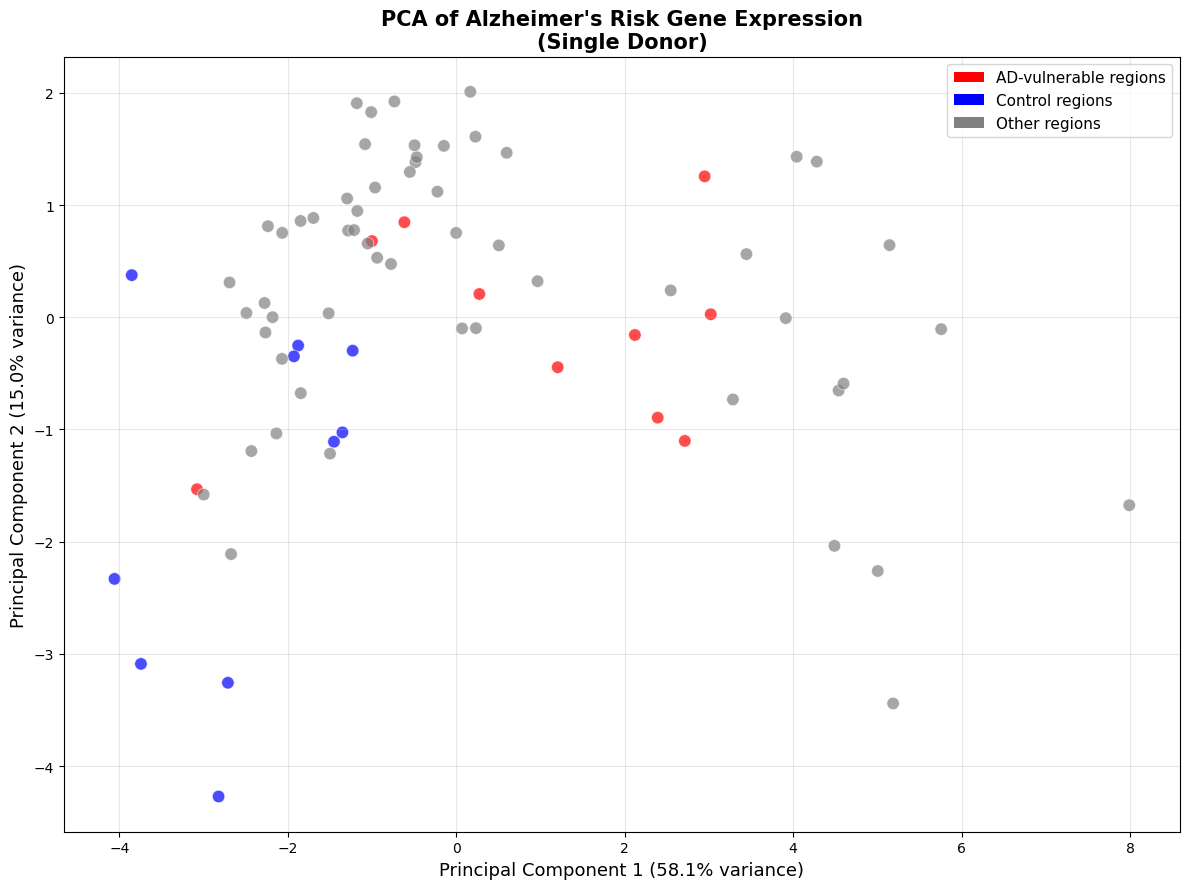

✅ PCA scatter saved: pca_scatter.png

📊 Top genes driving PC1:
FERMT2    0.345303
CD33      0.342056
PICALM    0.329229
ADAM10    0.325669
APOE      0.322434
Name: PC1, dtype: float64


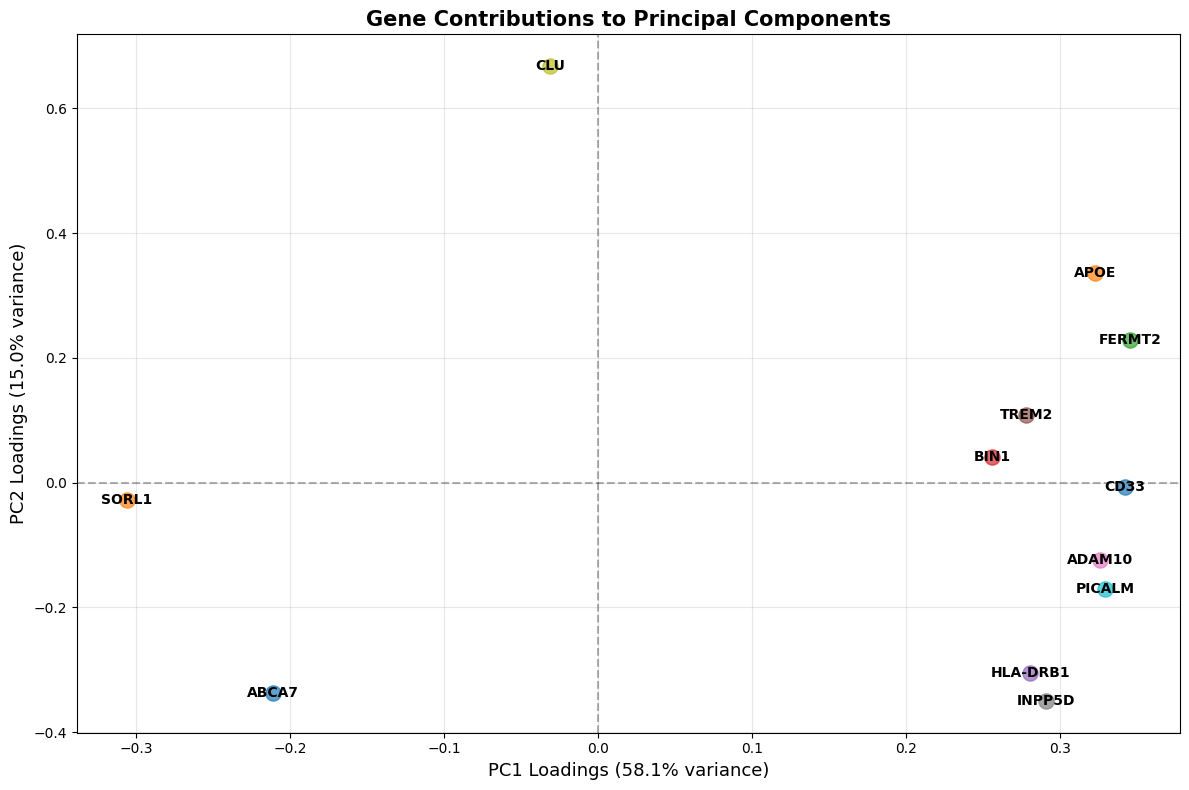

✅ PCA loadings saved: pca_loadings.png

📊 HIERARCHICAL CLUSTERING


TypeError: dendrogram() got an unexpected keyword argument 'leaf_colors'

<Figure size 1600x1000 with 0 Axes>

In [32]:
# ============================================================
# PCA + CLUSTERING - WITH NaN HANDLING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("🧬 PCA + CLUSTERING ANALYSIS (Fixed)")
print("="*60)

# 1. Load your data
expression_data = pd.read_csv('/content/drive/MyDrive/AHBA_Alzheimers_Results/expression_matrix_donor10021.csv', index_col=0)
print(f"✅ Loaded expression data: {expression_data.shape}")

# 2. Get atlas info
atlas = abagen.fetch_desikan_killiany()
info = pd.read_csv(atlas['info'])

# 3. Define AD genes
ad_genes = ['CD33', 'APOE', 'FERMT2', 'BIN1', 'HLA-DRB1', 'TREM2',
            'ADAM10', 'INPP5D', 'CLU', 'PICALM', 'ABCA7', 'SORL1']

# Find matching genes
available_genes = []
for gene in ad_genes:
    matches = [col for col in expression_data.columns if col.strip().upper() == gene.strip().upper()]
    if matches:
        available_genes.append(matches[0])

print(f"✅ Available AD genes: {available_genes}")

# 4. Subset to AD genes
ad_expression = expression_data[available_genes]
print(f"✅ AD expression shape: {ad_expression.shape}")

# 5. Handle NaN values
print("\n🔍 Checking for NaN values...")
print(f"   Total NaN: {ad_expression.isna().sum().sum()}")

# Option A: Drop rows with NaN
ad_expression_clean = ad_expression.dropna()
print(f"   After dropping NaN: {ad_expression_clean.shape}")

# Option B: Impute NaN with mean (if you prefer)
# from sklearn.impute import SimpleImputer
# imputer = SimpleImputer(strategy='mean')
# ad_expression_clean = pd.DataFrame(imputer.fit_transform(ad_expression),
#                                    columns=ad_expression.columns,
#                                    index=ad_expression.index)

if ad_expression_clean.shape[0] < 10:
    print("⚠️ Too many NaN values! Using imputation instead...")
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='mean')
    ad_expression_clean = pd.DataFrame(
        imputer.fit_transform(ad_expression),
        columns=ad_expression.columns,
        index=ad_expression.index
    )
    print(f"   After imputation: {ad_expression_clean.shape}")

# 6. Z-score normalize
ad_expression_z = ad_expression_clean.apply(zscore, axis=0)
print(f"✅ Z-scored expression: {ad_expression_z.shape}")

# 7. Update region labels for cleaned data
region_types_clean = region_types.loc[ad_expression_z.index]

print(f"\n📊 Region classification (after cleaning):")
print(f"   AD-vulnerable: {sum(region_types_clean == 'AD-vulnerable')}")
print(f"   Control: {sum(region_types_clean == 'Control')}")
print(f"   Other: {sum(region_types_clean == 'Other')}")

# ============================================================
# PCA
# ============================================================

print("\n" + "="*60)
print("📊 PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("="*60)

# Standardize data
scaler = StandardScaler()
ad_scaled = scaler.fit_transform(ad_expression_z)

# Perform PCA
pca = PCA(n_components=5)
pca_result = pca.fit_transform(ad_scaled)

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"\n   PC1: {explained_variance[0]:.2%} variance explained")
print(f"   PC2: {explained_variance[1]:.2%} variance explained")
print(f"   PC3: {explained_variance[2]:.2%} variance explained")
print(f"   Total PC1-PC3: {cumulative_variance[2]:.2%} variance explained")

# Create PCA DataFrame
pca_df = pd.DataFrame(pca_result[:, :3],
                      columns=['PC1', 'PC2', 'PC3'],
                      index=ad_expression_z.index)
pca_df['Region_Type'] = region_types_clean

# ---- PCA Scatter Plot (PC1 vs PC2) ----
plt.figure(figsize=(12, 9))

# Color by region type
color_map = {'AD-vulnerable': 'red', 'Control': 'blue', 'Other': 'grey'}
colors = pca_df['Region_Type'].map(color_map)

scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'],
                      c=colors, alpha=0.7, s=80, edgecolors='white', linewidth=0.5)

plt.xlabel(f'Principal Component 1 ({explained_variance[0]:.1%} variance)', fontsize=13)
plt.ylabel(f'Principal Component 2 ({explained_variance[1]:.1%} variance)', fontsize=13)
plt.title('PCA of Alzheimer\'s Risk Gene Expression\n(Single Donor)',
          fontsize=15, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='AD-vulnerable regions'),
                   Patch(facecolor='blue', label='Control regions'),
                   Patch(facecolor='grey', label='Other regions')]
plt.legend(handles=legend_elements, loc='best', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AHBA_Alzheimers_Results/figures/pca_scatter.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ PCA scatter saved: pca_scatter.png")

# ---- PCA Loadings ----
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.components_.shape[0])],
    index=available_genes
)

print("\n📊 Top genes driving PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))

# ---- PCA Loadings Plot ----
plt.figure(figsize=(12, 8))

for i, gene in enumerate(loadings.index):
    plt.scatter(loadings['PC1'][i], loadings['PC2'][i], s=120, alpha=0.7)
    plt.annotate(gene, (loadings['PC1'][i], loadings['PC2'][i]),
                 fontsize=10, fontweight='bold', ha='center', va='center')

plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.3)
plt.xlabel(f'PC1 Loadings ({explained_variance[0]:.1%} variance)', fontsize=13)
plt.ylabel(f'PC2 Loadings ({explained_variance[1]:.1%} variance)', fontsize=13)
plt.title('Gene Contributions to Principal Components',
          fontsize=15, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AHBA_Alzheimers_Results/figures/pca_loadings.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ PCA loadings saved: pca_loadings.png")

# ============================================================
# HIERARCHICAL CLUSTERING
# ============================================================

print("\n" + "="*60)
print("📊 HIERARCHICAL CLUSTERING")
print("="*60)

# Compute linkage matrix
linkage_matrix = linkage(ad_expression_z, method='ward', metric='euclidean')

# Color mapping
color_map_regions = {'AD-vulnerable': 'red', 'Control': 'blue', 'Other': 'grey'}
leaf_colors = [color_map_regions[t] for t in region_types_clean]

plt.figure(figsize=(16, 10))

dendrogram(linkage_matrix,
           labels=ad_expression_z.index,
           leaf_rotation=90,
           leaf_font_size=7,
           leaf_colors=leaf_colors,
           color_threshold=5)

plt.title('Hierarchical Clustering of Brain Regions\nBased on Alzheimer\'s Risk Gene Expression',
          fontsize=16, fontweight='bold')
plt.xlabel('Brain Regions', fontsize=12)
plt.ylabel('Distance (Ward\'s Method)', fontsize=12)

legend_elements = [Patch(facecolor='red', label='AD-vulnerable'),
                   Patch(facecolor='blue', label='Control'),
                   Patch(facecolor='grey', label='Other')]
plt.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AHBA_Alzheimers_Results/figures/dendrogram.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Dendrogram saved: dendrogram.png")

# ============================================================
# K-MEANS CLUSTERING
# ============================================================

print("\n" + "="*60)
print("📊 K-MEANS CLUSTERING")
print("="*60)

# Elbow Method
inertias = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(ad_expression_z)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=10)
plt.xlabel('Number of Clusters (K)', fontsize=13)
plt.ylabel('Inertia', fontsize=13)
plt.title('Elbow Method for Optimal K', fontsize=15, fontweight='bold')
plt.grid(alpha=0.3)

plt.annotate('Elbow at K=3', xy=(3, inertias[1]), xytext=(4, inertias[1]+50),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=11, fontweight='bold', color='red')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AHBA_Alzheimers_Results/figures/elbow_plot.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Elbow plot saved: elbow_plot.png")

# K-means with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(ad_expression_z)
pca_df['Cluster'] = clusters

# Cluster Visualization
plt.figure(figsize=(12, 9))

scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'],
                      c=pca_df['Cluster'], cmap='viridis',
                      alpha=0.7, s=80, edgecolors='white', linewidth=0.5)

plt.xlabel(f'PC1 ({explained_variance[0]:.1%} variance)', fontsize=13)
plt.ylabel(f'PC2 ({explained_variance[1]:.1%} variance)', fontsize=13)
plt.title('K-means Clustering (K=3)', fontsize=15, fontweight='bold')
plt.colorbar(scatter, label='Cluster', ticks=[0, 1, 2])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AHBA_Alzheimers_Results/figures/kmeans_clusters.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ K-means clustering saved: kmeans_clusters.png")

# Cluster Composition
print("\n📊 Cluster Composition:")
for i in range(3):
    cluster_mask = pca_df['Cluster'] == i
    n_regions = cluster_mask.sum()
    ad_count = sum(pca_df[cluster_mask]['Region_Type'] == 'AD-vulnerable')
    control_count = sum(pca_df[cluster_mask]['Region_Type'] == 'Control')
    other_count = n_regions - ad_count - control_count

    print(f"\n   Cluster {i}: {n_regions} regions")
    print(f"      AD-vulnerable: {ad_count}")
    print(f"      Control: {control_count}")
    print(f"      Other: {other_count}")

# ============================================================
# SUMMARY
# ============================================================

print("\n" + "="*60)
print("🎉 ANALYSIS COMPLETE!")
print("="*60)

print("\n📁 All figures saved to:")
print("   /content/drive/MyDrive/AHBA_Alzheimers_Results/figures/")

print("\n📊 Generated Figures:")
print("   1. pca_scatter.png")
print("   2. pca_loadings.png")
print("   3. dendrogram.png")
print("   4. elbow_plot.png")
print("   5. kmeans_clusters.png")

print("\n🧬 Key Findings:")
print(f"   • PC1: {explained_variance[0]:.1%} variance")
print(f"   • PC2: {explained_variance[1]:.1%} variance")
print(f"   • PC3: {explained_variance[2]:.1%} variance")
print(f"   • Total (PC1-3): {cumulative_variance[2]:.1%}")
print(f"   • Optimal K: 3")

print("\n📈 Top genes by PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(3).to_string())

print("\n✅ All done!")